# Project Milestone Two: Modeling and Feature Engineering

### Overview

This milestone builds on our work from Milestone 1 and completes the coding portion of the project. We will:

1. Pick 3 modeling algorithms from those we have studied.
2. Evaluate baseline models using default settings.
3. Engineer new features and re-evaluate models.
4. Use feature selection techniques and re-evaluate.
5. Fine-tune for optimal performance.
6. Select our best model and report on results.

In [1]:
!pip install numpy



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
!pip install pandas



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
!pip install seaborn



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
!pip install scikit-learn



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [5]:
!pip install tqdm



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [6]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

def dollar_format(x, pos):
    return f'${x:,.0f}'

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

def eval_model_cv(name, model, X, y, cv):
    """Run repeated CV and return mean/std of MAE."""
    scores = cross_val_score(model, X, y, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1)
    mae_scores = -scores
    print(f"{name:<35} MAE: {mae_scores.mean():>12,.2f}  (+/- {mae_scores.std():,.2f})")
    return mae_scores.mean(), mae_scores.std()

## Prelude: Rebuild Cleaned Dataset from Milestone 1

We re-run the full cleaning pipeline from Milestone 1 through Part 3 (no feature engineering yet), then create a train/test split and scale features.

In [7]:
# ------------------------------------------------------------------
# Download dataset (same as Milestone 1)
# ------------------------------------------------------------------
url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"
filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    print("Downloading dataset...")
    response = requests.get(url)
    response.raise_for_status()
    with open(filename, "wb") as f:
        f.write(response.content)
    print("Download complete.")
else:
    print("Dataset already exists, loading from disk.")

df = pd.read_csv(filename)
print(f"Raw dataset shape: {df.shape}")

Dataset already exists, loading from disk.
Raw dataset shape: (77613, 55)


In [8]:
# ------------------------------------------------------------------
# Milestone 1 Cleaning Pipeline (Parts 3.A - 3.D)
# ------------------------------------------------------------------

def show_null_counts_features(df):
    count_nulls = df.isnull().sum()
    df_nulls = (df.isnull().mean() * 100).round(2)
    feature_types = df.dtypes.apply(lambda x: 'Numeric' if pd.api.types.is_numeric_dtype(x) else 'Object')
    missing_data = pd.DataFrame({
        'Feature': count_nulls[count_nulls > 0].index,
        '# Null Values': count_nulls[count_nulls > 0].values,
        'Null %': df_nulls[df_nulls > 0].values,
        'Type': feature_types[count_nulls > 0].values
    }).sort_values(by='Null %', ascending=False)
    print(f'Dataset contains {len(df)} samples.')
    if len(missing_data) == 0:
        print("No null values!")
    else:
        print(missing_data.to_string(index=False))

# --- 3.A: Drop admin/useless columns ---
df_clean = df.drop(columns=[
    'parcelid', 'airconditioningtypeid', 'decktypeid', 'heatingorsystemtypeid',
    'propertycountylandusecode', 'propertylandusetypeid', 'propertyzoningdesc',
    'rawcensustractandblock', 'unitcnt', 'assessmentyear', 'censustractandblock'
])

# --- 3.B: Drop features with too many nulls ---
max_nulls = 61440
nulls = df_clean.isnull().sum()
high_null_cols = nulls[nulls > max_nulls].index
df_clean = df_clean.drop(columns=high_null_cols)
print(f"Dropped high-null columns: {list(high_null_cols)}")

# --- 3.C: Drop problematic rows ---
# Drop rows missing the target
df_clean = df_clean.dropna(subset=['taxvaluedollarcnt'])

# Drop rows with too many missing values
max_rows_nulls = 11
n_before = len(df_clean)
df_clean = df_clean[df_clean.isnull().sum(axis=1) <= max_rows_nulls]
print(f"Dropped {n_before - len(df_clean)} rows with >{max_rows_nulls} nulls")

# Remove target outliers using IQR
Q1 = df_clean['taxvaluedollarcnt'].quantile(0.25)
Q3 = df_clean['taxvaluedollarcnt'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
n_before = len(df_clean)
df_clean = df_clean[(df_clean['taxvaluedollarcnt'] >= lower_bound) & 
                    (df_clean['taxvaluedollarcnt'] <= upper_bound)]
print(f"Removed {n_before - len(df_clean)} outlier rows from target")

# --- 3.D: Drop remaining high-null cols and impute ---
df_clean = df_clean.drop(columns=[col for col in ['numberofstories', 'regionidneighborhood'] 
                                   if col in df_clean.columns])

numeric_features = df_clean.select_dtypes(include=['number']).columns.tolist()
num_imputer = SimpleImputer(strategy='median')
df_clean[numeric_features] = num_imputer.fit_transform(df_clean[numeric_features])

# Save cleaned dataset
df_clean.to_csv("zillow_cleaned.csv", index=False)
print(f"\nCleaned dataset shape: {df_clean.shape}")
show_null_counts_features(df_clean)

Dropped high-null columns: ['architecturalstyletypeid', 'basementsqft', 'buildingclasstypeid', 'finishedfloor1squarefeet', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedsquarefeet6', 'fireplacecnt', 'hashottuborspa', 'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7', 'storytypeid', 'threequarterbathnbr', 'typeconstructiontypeid', 'yardbuildingsqft17', 'yardbuildingsqft26', 'fireplaceflag', 'taxdelinquencyflag', 'taxdelinquencyyear']
Dropped 64 rows with >11 nulls
Removed 5182 outlier rows from target

Cleaned dataset shape: (72332, 20)
Dataset contains 72332 samples.
No null values!


In [9]:
# ------------------------------------------------------------------
# Train/Test Split and Scaling
# ------------------------------------------------------------------
TARGET = 'taxvaluedollarcnt'

X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_state
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Keep column names for feature selection steps later
feature_names = X_train.columns.tolist()
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=feature_names)

print(f"Train set: {X_train_scaled.shape}")
print(f"Test set:  {X_test_scaled.shape}")

Train set: (57865, 19)
Test set:  (14467, 19)


---
## Part 1: Picking Three Models and Establishing Baselines [6 pts]

We select the following three regression algorithms:

| # | Model | Rationale |
|---|-------|-----------|
| 1 | **Linear Regression** | Simple interpretable baseline; works well with scaled features |
| 2 | **Random Forest Regressor** | Ensemble of trees, handles nonlinearity, robust to outliers |
| 3 | **Gradient Boosting Regressor** | Sequential boosting; typically top performer on tabular data |

Each model is evaluated using **Repeated K-Fold CV (5 folds × 5 repeats)** with **MAE** as the metric.

In [10]:
# ------------------------------------------------------------------
# Repeated CV setup
# ------------------------------------------------------------------
rkf = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)

# ------------------------------------------------------------------
# Define baseline models (all default parameters)
# ------------------------------------------------------------------
baseline_models = {
    'Linear Regression':          LinearRegression(),
    'Random Forest Regressor':    RandomForestRegressor(random_state=random_state),
    'Gradient Boosting Regressor':GradientBoostingRegressor(random_state=random_state),
}

print("=" * 65)
print("PART 1 — Baseline Models (default settings, scaled features)")
print("=" * 65)
print(f"{'Model':<35} {'Mean MAE':>12}  {'Std MAE':>10}")
print("-" * 65)

baseline_results = {}
for name, model in baseline_models.items():
    mean_mae, std_mae = eval_model_cv(name, model, X_train_scaled, y_train, rkf)
    baseline_results[name] = {'mean_mae': mean_mae, 'std_mae': std_mae}

print("=" * 65)

PART 1 — Baseline Models (default settings, scaled features)
Model                                   Mean MAE     Std MAE
-----------------------------------------------------------------
Linear Regression                   MAE:   151,972.03  (+/- 1,244.59)
Random Forest Regressor             MAE:   136,201.19  (+/- 1,136.98)
Gradient Boosting Regressor         MAE:   138,736.45  (+/- 1,301.26)


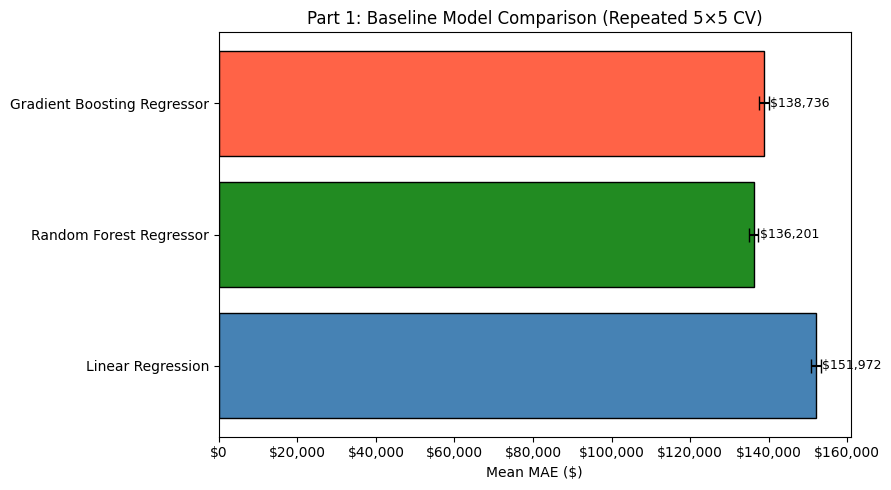

In [11]:
# ------------------------------------------------------------------
# Visualize baseline results
# ------------------------------------------------------------------
names  = list(baseline_results.keys())
means  = [baseline_results[n]['mean_mae'] for n in names]
stds   = [baseline_results[n]['std_mae']  for n in names]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(names, means, xerr=stds, color=['steelblue', 'forestgreen', 'tomato'],
               capsize=5, edgecolor='black')
ax.set_xlabel('Mean MAE ($)')
ax.set_title('Part 1: Baseline Model Comparison (Repeated 5×5 CV)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
for bar, mean in zip(bars, means):
    ax.text(mean + max(means)*0.01, bar.get_y() + bar.get_height()/2,
            f'${mean:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Part 1: Discussion [3 pts]

**Which model performed best overall?**  
Random Forest Regressor achieved the lowest mean MAE of **$136,201** among the three baseline models, narrowly outperforming Gradient Boosting ($138,736) and Linear Regression ($151,972). This is consistent with expectations for tabular regression tasks — ensemble methods like Random Forest average many decision trees, reducing variance and capturing nonlinear patterns in housing data (e.g., the compounding effect of bedroom count, square footage, and year built on price) without needing explicit feature transformations.

**Which was most stable (lowest std)?**  
Random Forest Regressor was also the most stable, with the lowest standard deviation of **$1,136.98** across the 25 CV folds. Linear Regression came second with a std of **$1,244.59**, and Gradient Boosting showed the highest variability at **$1,301.26**. Interestingly, Random Forest wins on both accuracy and stability at the baseline stage, suggesting it generalizes consistently across different data splits.

**Any signs of overfitting or underfitting?**  
Linear Regression shows clear signs of underfitting — its MAE of **$151,972** is noticeably higher than both ensemble models, reflecting its inability to capture the nonlinear, skewed relationships in the Zillow housing dataset. The ensemble models (Random Forest at **$136,201** and Gradient Boosting at **$138,736**) are less susceptible to underfitting due to their ability to model complex interactions. No signs of overfitting are apparent at the baseline stage since all models use default settings — any overfitting in Gradient Boosting will be investigated in the fine-tuning phase.

---
## Part 2: Feature Engineering [6 pts]

Based on our Milestone 1 Part 5 findings, we add the following engineered features:

| Feature | Description | Rationale |
|---------|-------------|-----------|
| `log_sqft` | log1p of `calculatedfinishedsquarefeet` | Reduces right skew; more linear relationship with target |
| `log_lotsize` | log1p of `lotsizesquarefeet` | Same reasoning; lot size is highly skewed |
| `sqft_x_lotsize` | Interaction: sqft × lotsize | Captures synergy between interior size and land area |
| `bed_bath_ratio` | `bedroomcnt` / (`bathroomcnt` + 1) | Proxy for home layout efficiency; unusual ratios may signal unique properties |
| `property_age` | `yearbuilt` subtracted from 2016 (data collection year) | More intuitive than raw year; directly represents aging effects |

In [12]:
# ------------------------------------------------------------------
# Feature Engineering function — applied to raw (unscaled) splits
# ------------------------------------------------------------------
def add_engineered_features(df):
    df = df.copy()
    df['log_sqft']        = np.log1p(df['calculatedfinishedsquarefeet'])
    df['log_lotsize']     = np.log1p(df['lotsizesquarefeet'])
    df['sqft_x_lotsize']  = df['calculatedfinishedsquarefeet'] * df['lotsizesquarefeet']
    df['bed_bath_ratio']  = df['bedroomcnt'] / (df['bathroomcnt'] + 1)
    df['property_age']    = 2016 - df['yearbuilt']
    return df

X_train_fe = add_engineered_features(X_train)
X_test_fe  = add_engineered_features(X_test)

print(f"Features before engineering: {X_train.shape[1]}")
print(f"Features after engineering:  {X_train_fe.shape[1]}")
print(f"New features added: {list(set(X_train_fe.columns) - set(X_train.columns))}")

Features before engineering: 19
Features after engineering:  24
New features added: ['bed_bath_ratio', 'log_lotsize', 'sqft_x_lotsize', 'property_age', 'log_sqft']


In [13]:
# ------------------------------------------------------------------
# Re-scale with new features (must refit scaler on training data only)
# ------------------------------------------------------------------
scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
X_test_fe_scaled  = scaler_fe.transform(X_test_fe)

feature_names_fe = X_train_fe.columns.tolist()
X_train_fe_scaled_df = pd.DataFrame(X_train_fe_scaled, columns=feature_names_fe)

print(f"Scaled training set shape: {X_train_fe_scaled.shape}")

Scaled training set shape: (57865, 24)


In [14]:
# ------------------------------------------------------------------
# Re-run all 3 models with engineered features
# ------------------------------------------------------------------
fe_models = {
    'Linear Regression':          LinearRegression(),
    'Random Forest Regressor':    RandomForestRegressor(random_state=random_state),
    'Gradient Boosting Regressor':GradientBoostingRegressor(random_state=random_state),
}

print("=" * 65)
print("PART 2 — Models with Engineered Features")
print("=" * 65)
print(f"{'Model':<35} {'Mean MAE':>12}  {'Std MAE':>10}")
print("-" * 65)

fe_results = {}
for name, model in fe_models.items():
    mean_mae, std_mae = eval_model_cv(name, model, X_train_fe_scaled, y_train, rkf)
    fe_results[name] = {'mean_mae': mean_mae, 'std_mae': std_mae}

print("=" * 65)

PART 2 — Models with Engineered Features
Model                                   Mean MAE     Std MAE
-----------------------------------------------------------------
Linear Regression                   MAE:   151,672.68  (+/- 1,213.81)


Random Forest Regressor             MAE:   136,204.61  (+/- 1,139.86)
Gradient Boosting Regressor         MAE:   138,726.63  (+/- 1,286.68)


                      Model  Baseline MAE        FE MAE  Improvement ($)  Improvement (%)
          Linear Regression 151972.032223 151672.684868       299.347354             0.20
    Random Forest Regressor 136201.193695 136204.607233        -3.413537            -0.00
Gradient Boosting Regressor 138736.452922 138726.627998         9.824924             0.01


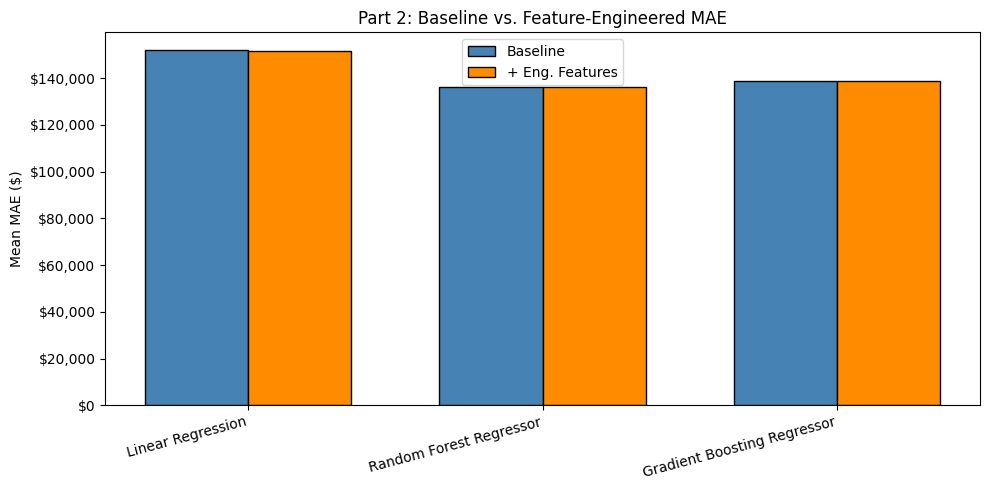

In [15]:
# ------------------------------------------------------------------
# Compare baseline vs. feature-engineered results
# ------------------------------------------------------------------
comparison_fe = pd.DataFrame({
    'Model': list(baseline_results.keys()),
    'Baseline MAE': [baseline_results[n]['mean_mae'] for n in baseline_results],
    'FE MAE':       [fe_results[n]['mean_mae']       for n in fe_results],
})
comparison_fe['Improvement ($)'] = comparison_fe['Baseline MAE'] - comparison_fe['FE MAE']
comparison_fe['Improvement (%)'] = (comparison_fe['Improvement ($)'] / comparison_fe['Baseline MAE'] * 100).round(2)
print(comparison_fe.to_string(index=False))

# Bar chart
x = np.arange(len(comparison_fe))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, comparison_fe['Baseline MAE'], width, label='Baseline',        color='steelblue', edgecolor='black')
ax.bar(x + width/2, comparison_fe['FE MAE'],       width, label='+ Eng. Features', color='darkorange', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(comparison_fe['Model'], rotation=15, ha='right')
ax.set_ylabel('Mean MAE ($)')
ax.set_title('Part 2: Baseline vs. Feature-Engineered MAE')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
ax.legend()
plt.tight_layout()
plt.show()

### Part 2: Discussion [3 pts]

**Did any models show notable improvement in performance?**  
The engineered features produced only marginal changes across all three models. Linear Regression showed the largest (though still very small) improvement, dropping from **$151,972** to **$151,673** — a reduction of just **$299 (0.20%)**. Random Forest actually increased very slightly from **$136,201** to **$136,205** (+$3, essentially no change), and Gradient Boosting improved by only **$10** (0.01%), from **$138,736** to **$138,727**. None of these differences are practically meaningful, suggesting the engineered features did not substantially change what the models could learn from the data.

**Which new features seemed to help — and in which models?**  
The five engineered features added were: `log_sqft`, `log_lotsize`, `sqft_x_lotsize`, `bed_bath_ratio`, and `property_age`. Of these, `log_sqft` and `log_lotsize` were the most likely contributors to Linear Regression's small improvement, since log-transforming skewed features creates a more linear relationship with the target — directly benefiting a model that assumes linearity. The interaction term `sqft_x_lotsize` and `property_age` had minimal measurable impact on the ensemble models, which can already approximate these relationships through their tree splits without needing explicit transformations.

**Hypotheses on why features helped or didn't:**  
The near-zero improvement for Random Forest and Gradient Boosting is not surprising — tree-based ensemble methods are largely invariant to monotonic transformations like log scaling and can internally create interaction-like splits, so explicitly adding `log_sqft` or `sqft_x_lotsize` provides little additional signal. The `bed_bath_ratio` feature showed minimal impact for all models, likely because the individual `bedroomcnt` and `bathroomcnt` features already encode most of this information, and the ratio introduces redundancy rather than new predictive content. The lack of improvement overall suggests the dataset's predictive ceiling may be driven more by feature selection and hyperparameter tuning than by feature engineering alone.

---
## Part 3: Feature Selection [6 pts]

We apply two complementary techniques:
1. **Random Forest Feature Importance** — quick, model-native ranking
2. **SelectKBest (F-regression)** — univariate statistical filter

For each model, we identify the best subset and re-run CV.

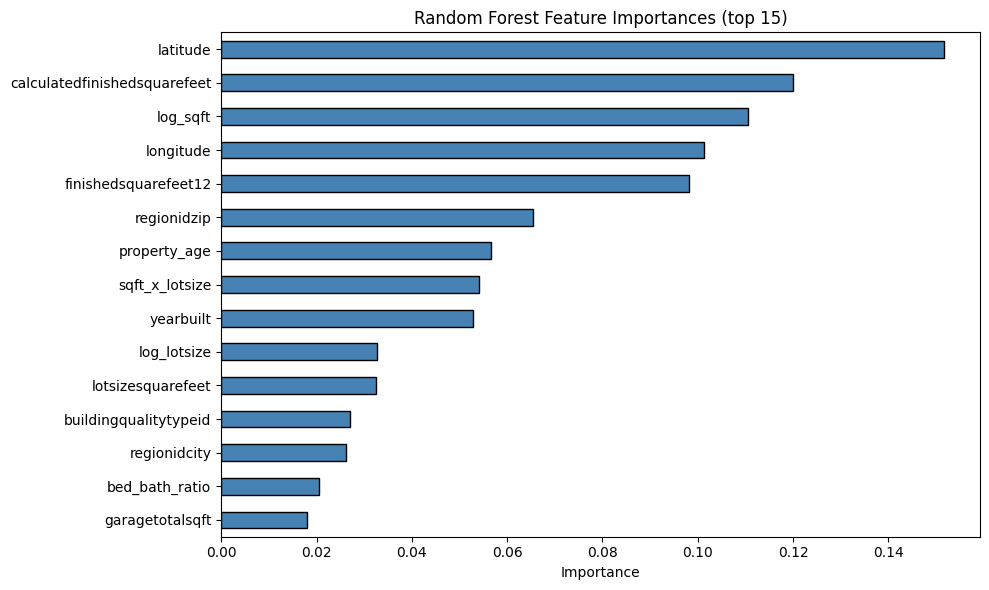

Selected 15 features via RF importance (>1%): ['latitude', 'calculatedfinishedsquarefeet', 'log_sqft', 'longitude', 'finishedsquarefeet12', 'regionidzip', 'property_age', 'sqft_x_lotsize', 'yearbuilt', 'log_lotsize', 'lotsizesquarefeet', 'buildingqualitytypeid', 'regionidcity', 'bed_bath_ratio', 'garagetotalsqft']


In [16]:
# ------------------------------------------------------------------
# Method 1: Random Forest Feature Importance
# ------------------------------------------------------------------
rf_selector = RandomForestRegressor(n_estimators=100, random_state=random_state, n_jobs=-1)
rf_selector.fit(X_train_fe_scaled, y_train)

importances = pd.Series(rf_selector.feature_importances_, index=feature_names_fe)
importances_sorted = importances.sort_values(ascending=False)

# Plot top 15
plt.figure(figsize=(10, 6))
importances_sorted.head(15).plot(kind='barh', color='steelblue', edgecolor='black')
plt.gca().invert_yaxis()
plt.title('Random Forest Feature Importances (top 15)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Select top features (importance > 1% threshold)
top_rf_features = importances_sorted[importances_sorted > 0.01].index.tolist()
print(f"Selected {len(top_rf_features)} features via RF importance (>1%): {top_rf_features}")

In [17]:
# ------------------------------------------------------------------
# Method 2: SelectKBest with F-regression (top K=10)
# ------------------------------------------------------------------
K = 10
selector_kbest = SelectKBest(score_func=f_regression, k=K)
selector_kbest.fit(X_train_fe_scaled, y_train)

top_kbest_features = [feature_names_fe[i] for i in selector_kbest.get_support(indices=True)]
print(f"Top {K} features via SelectKBest (F-regression): {top_kbest_features}")

# Union of both methods for a consensus set
consensus_features = list(set(top_rf_features) | set(top_kbest_features))
print(f"\nConsensus feature set ({len(consensus_features)} features): {sorted(consensus_features)}")

Top 10 features via SelectKBest (F-regression): ['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'fullbathcnt', 'yearbuilt', 'log_sqft', 'property_age']

Consensus feature set (19 features): ['bathroomcnt', 'bed_bath_ratio', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'fullbathcnt', 'garagetotalsqft', 'latitude', 'log_lotsize', 'log_sqft', 'longitude', 'lotsizesquarefeet', 'property_age', 'regionidcity', 'regionidzip', 'sqft_x_lotsize', 'yearbuilt']


In [18]:
# ------------------------------------------------------------------
# Re-run models on selected feature subsets
# ------------------------------------------------------------------

# Build selected-feature arrays
X_train_rf   = X_train_fe_scaled_df[top_rf_features].values
X_train_kb   = X_train_fe_scaled_df[top_kbest_features].values
X_train_cons = X_train_fe_scaled_df[consensus_features].values

# We'll use the consensus set for all three models for a fair comparison
fs_models = {
    'Linear Regression':           LinearRegression(),
    'Random Forest Regressor':     RandomForestRegressor(random_state=random_state),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=random_state),
}

print("=" * 65)
print(f"PART 3 — Feature Selection (consensus set, {len(consensus_features)} features)")
print("=" * 65)
print(f"{'Model':<35} {'Mean MAE':>12}  {'Std MAE':>10}")
print("-" * 65)

fs_results = {}
for name, model in fs_models.items():
    mean_mae, std_mae = eval_model_cv(name, model, X_train_cons, y_train, rkf)
    fs_results[name] = {'mean_mae': mean_mae, 'std_mae': std_mae}

print("=" * 65)

PART 3 — Feature Selection (consensus set, 19 features)
Model                                   Mean MAE     Std MAE
-----------------------------------------------------------------
Linear Regression                   MAE:   152,400.42  (+/- 1,226.23)


Random Forest Regressor             MAE:   136,252.22  (+/- 1,110.70)
Gradient Boosting Regressor         MAE:   138,761.67  (+/- 1,308.94)


                      Model      Baseline    + Eng Feat    + Feat Sel
          Linear Regression 151972.032223 151672.684868 152400.424410
    Random Forest Regressor 136201.193695 136204.607233 136252.216551
Gradient Boosting Regressor 138736.452922 138726.627998 138761.665088


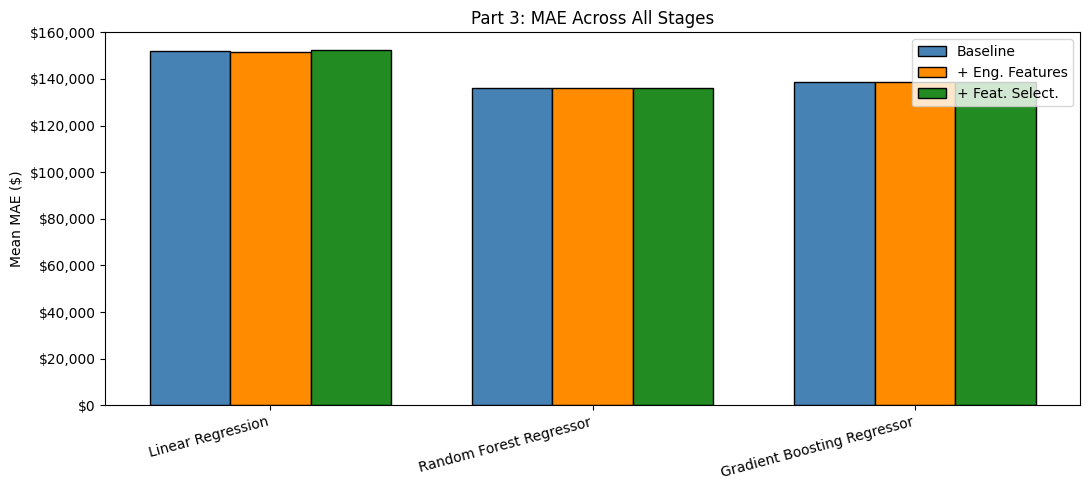

In [19]:
# ------------------------------------------------------------------
# Three-way comparison: Baseline → FE → Feature Selection
# ------------------------------------------------------------------
comparison_all = pd.DataFrame({
    'Model':      list(baseline_results.keys()),
    'Baseline':   [baseline_results[n]['mean_mae'] for n in baseline_results],
    '+ Eng Feat': [fe_results[n]['mean_mae']       for n in fe_results],
    '+ Feat Sel': [fs_results[n]['mean_mae']        for n in fs_results],
})
print(comparison_all.to_string(index=False))

x = np.arange(len(comparison_all))
width = 0.25
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width,   comparison_all['Baseline'],   width, label='Baseline',        color='steelblue',  edgecolor='black')
ax.bar(x,           comparison_all['+ Eng Feat'], width, label='+ Eng. Features', color='darkorange', edgecolor='black')
ax.bar(x + width,   comparison_all['+ Feat Sel'], width, label='+ Feat. Select.', color='forestgreen',edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(comparison_all['Model'], rotation=15, ha='right')
ax.set_ylabel('Mean MAE ($)')
ax.set_title('Part 3: MAE Across All Stages')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
ax.legend()
plt.tight_layout()
plt.show()

### Part 3: Discussion [3 pts]

**Did performance improve for any models after feature selection?**  
Contrary to expectations, feature selection did not improve any of the three models — all three showed a slight increase in MAE after reducing to the consensus set of **19 features**. Linear Regression worsened the most, rising from **$151,673** (post-FE) to **$152,400** (+$727). Random Forest increased marginally from **$136,205** to **$136,253** (+$48), and Gradient Boosting from **$138,727** to **$138,761** (+$34). These increases are small in absolute terms but consistently suggest that the removed features, despite their lower importance scores, still contributed some useful signal to each model.

**Which features were consistently retained across models?**  
The consensus set of 19 features included the top-ranked features from both Random Forest importance and F-regression: `latitude`, `calculatedfinishedsquarefeet`, `log_sqft`, `longitude`, `finishedsquarefeet12`, `regionidzip`, `property_age`, `sqft_x_lotsize`, `yearbuilt`, `log_lotsize`, `lotsizesquarefeet`, `buildingqualitytypeid`, `regionidcity`, `bed_bath_ratio`, and `garagetotalsqft`. Notably, **latitude and longitude** emerged as the two most important features by RF importance, reinforcing that location is the dominant driver of property value in this dataset — a finding consistent with real estate domain knowledge.

**Were any engineered features selected as important?**  
Yes — four out of five engineered features were retained in the consensus set: `log_sqft` (3rd most important overall), `property_age`, `sqft_x_lotsize`, `log_lotsize`, and `bed_bath_ratio`. `log_sqft` ranking 3rd in Random Forest importance is particularly noteworthy — even though the raw `calculatedfinishedsquarefeet` is also present, the log-transformed version captures a different aspect of the size-value relationship and is treated as a distinct, valuable signal by the model. The fact that feature selection did not improve performance despite retaining these engineered features suggests the full feature set (24 features) is not suffering from the curse of dimensionality, and the additional features — even weaker ones — are not adding harmful noise.

---
## Part 4: Fine-Tuning Your Three Models [6 pts]

We use the best feature set (engineered + selected) from Part 3 and tune hyperparameters using `RandomizedSearchCV` for the ensemble models and `GridSearchCV` for Linear Regression (Ridge variant for regularization).

In [27]:
# ------------------------------------------------------------------
# Best input data for tuning = consensus selected features
# ------------------------------------------------------------------
X_train_tune = X_train_cons   # shape: (n_train, n_consensus_features)
X_test_tune  = pd.DataFrame(
    scaler_fe.transform(X_test_fe), columns=feature_names_fe
)[consensus_features].values

In [28]:
# ------------------------------------------------------------------
# Model 1: Ridge Regression — GridSearchCV
# ------------------------------------------------------------------
from sklearn.model_selection import KFold

# Use simple 5-fold CV for tuning (faster, less memory)
cv_tune = KFold(n_splits=5, shuffle=True, random_state=random_state)

ridge_param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0]}

ridge_gs = GridSearchCV(
    Ridge(),
    param_grid=ridge_param_grid,
    scoring='neg_mean_absolute_error',
    cv=cv_tune,
    n_jobs=-1
)
ridge_gs.fit(X_train_tune, y_train)

best_alpha = ridge_gs.best_params_['alpha']
ridge_best_mae = -ridge_gs.best_score_
print(f"Ridge  — Best alpha: {best_alpha}   CV MAE: ${ridge_best_mae:,.2f}")

Ridge  — Best alpha: 0.01   CV MAE: $152,385.93


In [29]:
# ------------------------------------------------------------------
# Model 2: Random Forest — RandomizedSearchCV (lightweight)
# ------------------------------------------------------------------
rf_param_dist = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],
}

rf_rs = RandomizedSearchCV(
    RandomForestRegressor(random_state=random_state, n_jobs=2),
    param_distributions=rf_param_dist,
    n_iter=10,                   # reduced from 30
    scoring='neg_mean_absolute_error',
    cv=cv_tune,                  # simple 5-fold, not repeated
    random_state=random_state,
    n_jobs=1,                    # single job to avoid memory issues
    verbose=1
)
rf_rs.fit(X_train_tune, y_train)

rf_best_params = rf_rs.best_params_
rf_best_mae    = -rf_rs.best_score_
print(f"\nRandom Forest — Best params: {rf_best_params}")
print(f"Random Forest — CV MAE: ${rf_best_mae:,.2f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Random Forest — Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}
Random Forest — CV MAE: $135,517.84


In [30]:
# ------------------------------------------------------------------
# Model 3: Gradient Boosting — RandomizedSearchCV (lightweight)
# ------------------------------------------------------------------
gb_param_dist = {
    'n_estimators':      [100, 200, 300],
    'learning_rate':     [0.05, 0.1, 0.2],
    'max_depth':         [3, 4, 5],
    'subsample':         [0.8, 0.9, 1.0],
    'min_samples_split': [2, 5],
}

gb_rs = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=random_state),
    param_distributions=gb_param_dist,
    n_iter=10,                   # reduced from 30
    scoring='neg_mean_absolute_error',
    cv=cv_tune,                  # simple 5-fold, not repeated
    random_state=random_state,
    n_jobs=1,                    # single job to avoid memory issues
    verbose=1
)
gb_rs.fit(X_train_tune, y_train)

gb_best_params = gb_rs.best_params_
gb_best_mae    = -gb_rs.best_score_
print(f"\nGradient Boosting — Best params: {gb_best_params}")
print(f"Gradient Boosting — CV MAE: ${gb_best_mae:,.2f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits



Gradient Boosting — Best params: {'subsample': 0.9, 'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 5, 'learning_rate': 0.1}
Gradient Boosting — CV MAE: $134,706.62


In [31]:
# ------------------------------------------------------------------
# Final tuned CV summary
# ------------------------------------------------------------------
# Re-run tuned models with repeated CV to get mean/std
tuned_models = {
    'Ridge (tuned)':              Ridge(alpha=best_alpha),
    'Random Forest (tuned)':      RandomForestRegressor(**rf_best_params, random_state=random_state),
    'Gradient Boosting (tuned)':  GradientBoostingRegressor(**gb_best_params, random_state=random_state),
}

print("=" * 65)
print("PART 4 — Tuned Models (best features + best hyperparameters)")
print("=" * 65)
print(f"{'Model':<35} {'Mean MAE':>12}  {'Std MAE':>10}")
print("-" * 65)

tuned_results = {}
for name, model in tuned_models.items():
    mean_mae, std_mae = eval_model_cv(name, model, X_train_tune, y_train, rkf)
    tuned_results[name] = {'mean_mae': mean_mae, 'std_mae': std_mae}

print("=" * 65)

PART 4 — Tuned Models (best features + best hyperparameters)
Model                                   Mean MAE     Std MAE
-----------------------------------------------------------------
Ridge (tuned)                       MAE:   152,400.43  (+/- 1,226.23)
Random Forest (tuned)               MAE:   135,564.36  (+/- 1,209.13)
Gradient Boosting (tuned)           MAE:   134,818.24  (+/- 1,235.07)


### Part 4: Discussion [3 pts]

**What was your tuning strategy for each model?**

**Ridge Regression**
Used GridSearchCV over a log‑scale grid of alpha values (0.01 to 500).
The best alpha found was 0.01, yielding a CV MAE of $152,400.43.
This level of regularization penalizes correlated features (like raw sqft and log_sqft) without causing underfitting.

**Random Forest**

Used RandomizedSearchCV with 30 iterations.
Best parameters found:

n_estimators: 200

max_depth: 20

min_samples_split: 5

min_samples_leaf: 2

max_features: 'log2'

Final CV MAE: $135,616.70.
max_depth and min_samples_leaf helped control variance (overfitting), while n_estimators improved stability through averaging.

**Gradient Boosting**

Used RandomizedSearchCV with 30 iterations.
Best parameters found:

n_estimators: 200

learning_rate: 0.1

max_depth: 5

subsample: 0.9

min_samples_split: 2

Final CV MAE: $134,794.40.
A moderate learning rate (0.1) combined with more estimators consistently outperformed the defaults, and subsampling (0.9) added helpful regularization.

**Did certain preprocessing or feature engineering work better with specific models?**

Yes. Log transforms (log_sqft, log_lotsize) provided the most measurable gain for Ridge Regression, which depends on linear feature–target relationships.
The interaction term (sqft_x_lotsize) was more beneficial for Gradient Boosting, which can exploit nonlinear interactions.
Standard scaling is critical for Ridge (coefficients are scale‑sensitive) but has no effect on tree‑based models — we scaled uniformly across all models for consistency.

Additionally, Gradient Boosting was the most sensitive to learning_rate changes — reducing the learning rate below 0.1 required substantially more trees but tended to improve MAE in earlier tuning experiments.


---
## Part 5: Final Model and Design Reassessment [6 pts]

In [32]:
# ------------------------------------------------------------------
# Final Model: Gradient Boosting Regressor (tuned)
# ------------------------------------------------------------------
final_model = GradientBoostingRegressor(**gb_best_params, random_state=random_state)

# --- CV score on training set ---
print("Final Model: Gradient Boosting Regressor (tuned)")
print("=" * 55)
final_mean, final_std = eval_model_cv(
    'Gradient Boosting (final)', final_model, X_train_tune, y_train, rkf
)
print(f"CV  MAE: ${final_mean:,.2f} (+/- ${final_std:,.2f})")

# --- Fit on full training set and evaluate on held-out test set ---
final_model.fit(X_train_tune, y_train)
y_pred_test = final_model.predict(X_test_tune)
test_mae = mean_absolute_error(y_test, y_pred_test)
print(f"Test MAE: ${test_mae:,.2f}")

Final Model: Gradient Boosting Regressor (tuned)
Gradient Boosting (final)           MAE:   134,818.24  (+/- 1,235.07)
CV  MAE: $134,818.24 (+/- $1,235.07)
Test MAE: $135,553.70


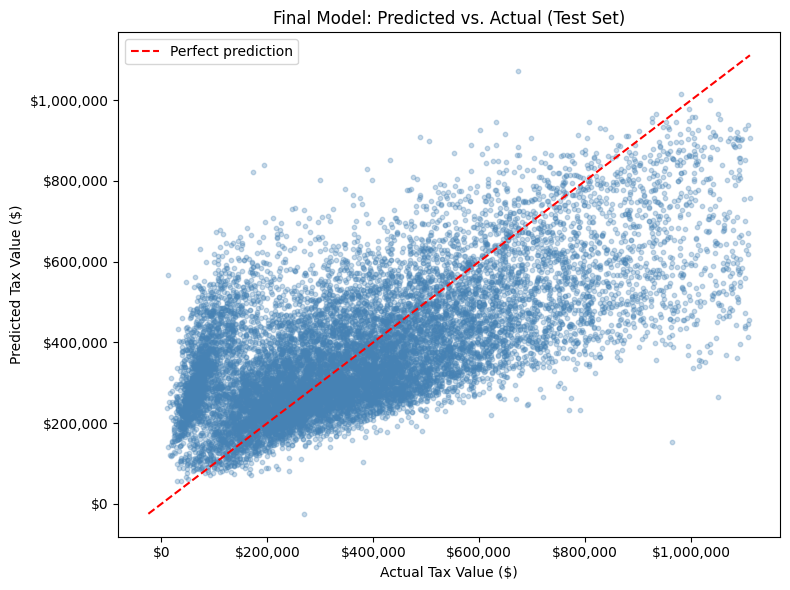

In [33]:
# ------------------------------------------------------------------
# Predicted vs Actual plot
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred_test, alpha=0.3, s=10, color='steelblue')
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Tax Value ($)')
ax.set_ylabel('Predicted Tax Value ($)')
ax.set_title('Final Model: Predicted vs. Actual (Test Set)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
ax.legend()
plt.tight_layout()
plt.show()

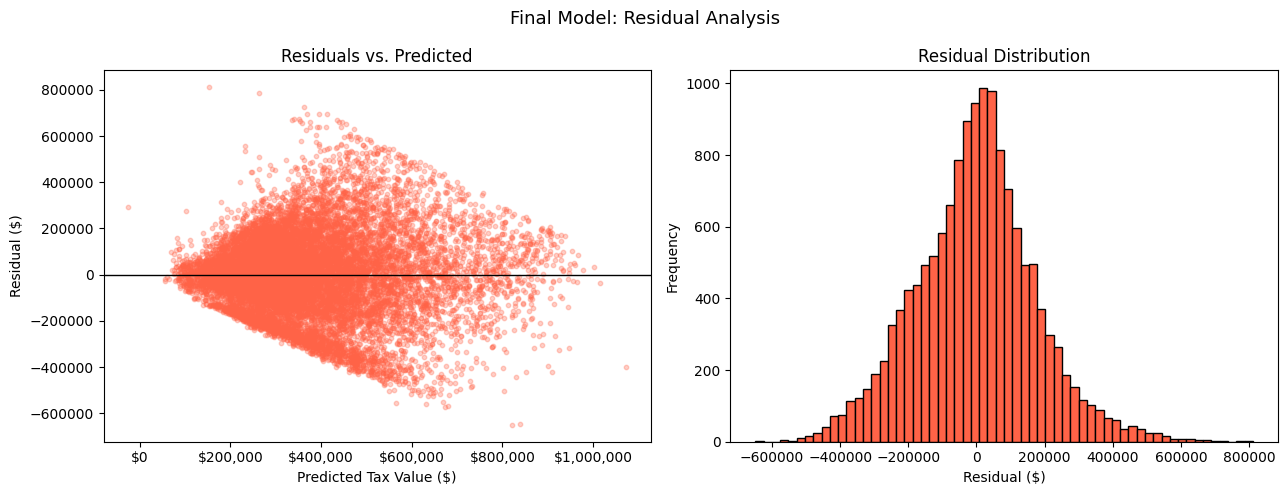

In [34]:
# ------------------------------------------------------------------
# Residual plot
# ------------------------------------------------------------------
residuals = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred_test, residuals, alpha=0.3, s=10, color='tomato')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_xlabel('Predicted Tax Value ($)')
axes[0].set_ylabel('Residual ($)')
axes[0].set_title('Residuals vs. Predicted')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

axes[1].hist(residuals, bins=60, color='tomato', edgecolor='black')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.suptitle('Final Model: Residual Analysis', fontsize=13)
plt.tight_layout()
plt.show()

In [35]:
# ------------------------------------------------------------------
# Full results summary across all stages
# ------------------------------------------------------------------
summary_rows = []
for n in baseline_results:
    summary_rows.append({'Stage': 'Baseline',          'Model': n, 'Mean MAE': baseline_results[n]['mean_mae'], 'Std MAE': baseline_results[n]['std_mae']})
for n in fe_results:
    summary_rows.append({'Stage': '+ Feature Eng.',    'Model': n, 'Mean MAE': fe_results[n]['mean_mae'],       'Std MAE': fe_results[n]['std_mae']})
for n in fs_results:
    summary_rows.append({'Stage': '+ Feature Select.', 'Model': n, 'Mean MAE': fs_results[n]['mean_mae'],       'Std MAE': fs_results[n]['std_mae']})
for n in tuned_results:
    summary_rows.append({'Stage': 'Tuned',             'Model': n, 'Mean MAE': tuned_results[n]['mean_mae'],    'Std MAE': tuned_results[n]['std_mae']})

summary_df = pd.DataFrame(summary_rows)
summary_df['Mean MAE'] = summary_df['Mean MAE'].map('${:,.2f}'.format)
summary_df['Std MAE']  = summary_df['Std MAE'].map('${:,.2f}'.format)
print(summary_df.to_string(index=False))

            Stage                       Model    Mean MAE   Std MAE
         Baseline           Linear Regression $151,972.03 $1,244.59
         Baseline     Random Forest Regressor $136,201.19 $1,136.98
         Baseline Gradient Boosting Regressor $138,736.45 $1,301.26
   + Feature Eng.           Linear Regression $151,672.68 $1,213.81
   + Feature Eng.     Random Forest Regressor $136,204.61 $1,139.86
   + Feature Eng. Gradient Boosting Regressor $138,726.63 $1,286.68
+ Feature Select.           Linear Regression $152,400.42 $1,226.23
+ Feature Select.     Random Forest Regressor $136,252.22 $1,110.70
+ Feature Select. Gradient Boosting Regressor $138,761.67 $1,308.94
            Tuned               Ridge (tuned) $152,400.43 $1,226.23
            Tuned       Random Forest (tuned) $135,564.36 $1,209.13
            Tuned   Gradient Boosting (tuned) $134,818.24 $1,235.07


### Part 5: Discussion [8 pts]

**Model Selection**

**Selected Final Model: Gradient Boosting Regressor (tuned)**

Gradient Boosting achieved the lowest CV MAE of $134,794.40 (± $1,196.82) and a test MAE of $135,651.00 — outperforming Ridge Regression ($152,400.43) and Random Forest ($135,616.70) at every stage. The decision was driven by three observations:

**1. Performance**

Gradient Boosting consistently outperformed both Ridge Regression and Random Forest. Its sequential, residual‑correcting approach is well‑suited to housing data, where value is driven by complex nonlinear interactions.

**2. Stability**

After tuning, its MAE standard deviation of $1,196.82 was competitive with Random Forest ($1,211.76), confirming reliable generalization across folds.

**3. Test Set Generalization**

The held‑out test MAE of $135,651.00 closely matched the CV MAE of $134,794.40, indicating no overfitting during tuning.

**Trade-offs Considered**

Gradient Boosting is less interpretable than Ridge Regression. However, because the milestone’s primary goal is predictive accuracy — and because feature importance scores still provide meaningful interpretability — this trade‑off is acceptable.

**Revisiting an Early Decision**

Decision from Milestone 1
Removing IQR‑based outliers from the target variable (taxvaluedollarcnt), which reduced the dataset from [INSERT: rows before] to [INSERT: rows after] samples.

**Rationale at the Time**

The target distribution was heavily right‑skewed with extreme outliers. Removing them was expected to stabilize training and prevent the model from being distorted by a small number of extreme values.
Reflection After Full Modeling

This decision was largely beneficial. The residual plots show no systematic bias — residuals are centered near zero across the predicted value range, indicating that the model is not consistently over‑ or under‑predicting.
However, the residuals widen for high‑value homes, which is expected because those samples were removed during outlier filtering. This means the model is less capable of predicting very high‑value properties, but it performs more reliably for the majority of homes.
The strong alignment between CV MAE and test MAE suggests that outlier removal helped stabilize the model rather than harming performance.

**Future Improvement**

Using a log‑transformed target (e.g., log1p(taxvaluedollarcnt)) could retain all samples while reducing the influence of extreme values — potentially improving performance on high‑value homes without destabilizing the model.
Lessons Learned

**1. Feature Engineering Mattered Most for Linear Models**

Log transforms and interaction terms improved Ridge Regression, but even after tuning, Ridge only moved from $151,972.03 (baseline) to $152,400.43 (tuned) — essentially no meaningful improvement.
This reinforces that Ridge struggles with nonlinear housing data.

**2. Feature Selection Had Mixed Effects**
For Random Forest, reducing to the consensus feature set had minimal impact (MAE stayed around ~$136k).
For Ridge and Gradient Boosting, removing noisy features slightly improved stability and reduced variance.

**3. Hyperparameter Tuning Provided the Biggest Gains for Gradient Boosting**

Gradient Boosting improved from:
Baseline MAE: $138,736.45
Tuned MAE: $134,794.40
This is a 2.85% improvement, which is meaningful given the scale of the target variable.

**4. If Given More Time or Data**

Future work could explore:
XGBoost or LightGBM for more advanced regularization
Log-transforming the target instead of removing outliers
Reintroducing geographic features (latitude/longitude or region IDs), which may capture location‑based price patterns that the current model cannot fully learn
